# Lecture 7: DataFrames, Plotting, and Linear Regression

In previous lectures we used lists, dictionaries, functions, and CSV files.
Today we use a pandas **DataFrame** to work with a whole table.

 Required packages: pandas, NumPy, and Matplotlib.


In [2]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = Path('mtcars.csv')
if not DATA_FILE.is_file():
    raise FileNotFoundError('Put mtcars.csv in the notebook working folder before running.')


# What is a DataFrame?

You already know how to store values in lists:

```python
models = ["Car A", "Car B"]
horsepower = [100, 150]
```

and how a dictionary connects a **key** to a **value**:

```python
data = {
    "model": ["Car A", "Car B"],
    "hp": [100, 150]
}
```

A pandas **DataFrame** turns this kind of data into a table. The dictionary keys become the **column names**, and the lists become the **columns**.

In [4]:
data = {
    "model": ["Car A", "Car B", "Car C"],
    "hp": [100, 150, 120],
    "mpg": [30.0, 22.0, 26.0]
}

small_df = pd.DataFrame(data)

small_df

,model,hp,mpg
0,Car A,100,30.0
1,Car B,150,22.0
2,Car C,120,26.0


A DataFrame has:

- **rows**: one observation or item,
- **columns**: one type of information,
- **column names**: labels used to access the data,
- an **index**: the row labels on the left (here `0, 1, 2`).

For this example:

```text
row    → one car
column → one property, such as hp or mpg
```

Every DataFrame knows its own size and the type of each column:

In [5]:
print("Shape (rows, columns):", small_df.shape)
print("Data types of the columns:")
print(small_df.dtypes)

Shape (rows, columns): (3, 3)
Data types of the columns:
model        str
hp         int64
mpg      float64
dtype: object


Integer columns hold whole numbers; floating-point columns hold decimals.
The text type can appear as `object`, `str`, or `string`, depending on the
pandas version and how the data was created.

A DataFrame lets us calculate with a whole column:


In [6]:
# The way we did it before: loop over a list
total = 0
for value in data["hp"]:
    total = total + value

average_loop = total / len(data["hp"])

# The DataFrame way: one method call
average_df = small_df["hp"].mean()

print("Average with a loop:     ", average_loop)
print("Average with a DataFrame:", average_df)

Average with a loop:      123.33333333333333
Average with a DataFrame: 123.33333333333333


## Read and inspect a CSV

Our file uses `;` between values. Pandas assumes commas unless we specify
the separator. After reading, check the column names and a few rows.
If everything appears in one long column, check the separator first.


In [10]:
df = pd.read_csv(DATA_FILE, sep=';')
print('Shape (rows, columns):', df.shape)
print('Columns:', list(df.columns))
df.head()


Shape (rows, columns): (32, 7)
Columns: ['model', 'mpg', 'cyl', 'disp', 'hp', 'wt', 'am']


,model,mpg,cyl,disp,hp,wt,am
0,Mazda RX4,21.0,6,160.0,110,2.620,1
1,Mazda RX4 Wag,21.0,6,160.0,110,2.875,1
2,Datsun 710,22.8,4,108.0,93,2.320,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.215,0
4,Hornet Sportabout,18.7,8,360.0,175,3.440,0


The dataset comes from a 1974 US car magazine test of 32 car models. The columns are:

| Column | Meaning | Unit |
|---|---|---|
| `model` | car model | |
| `mpg` | fuel economy | miles per US gallon |
| `cyl` | number of cylinders | |
| `disp` | engine displacement | cubic inches |
| `hp` | horsepower | hp |
| `wt` | vehicle weight | 1000 lb |
| `am` | transmission | `0` = automatic, `1` = manual |


In [11]:
df.info()
df.describe().round(2)


<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     str    
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   wt      32 non-null     float64
 6   am      32 non-null     int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 1.9 KB


,mpg,cyl,disp,hp,wt,am
count,32.00,32.00,32.00,32.00,32.00,32.00
mean,20.09,6.19,230.72,146.69,3.22,0.41
std,6.03,1.79,123.94,68.56,0.98,0.50
min,10.40,4.00,71.10,52.00,1.51,0.00
25%,15.42,4.00,120.82,96.50,2.58,0.00
50%,19.20,6.00,196.30,123.00,3.32,0.00
75%,22.80,8.00,326.00,180.00,3.61,1.00
max,33.90,8.00,472.00,335.00,5.42,1.00


`info()` shows column types and non-null counts. Compare each count with
the number of rows to identify missing values.

`describe()` gives numeric summaries: count, mean, standard deviation,
minimum, quartiles, and maximum. The 50% value is the median.
Category codes need interpretation: an average cylinder code or transmission
code is not the same kind of quantity as average horsepower.

Use `value_counts()` to count categories:


In [12]:
df["cyl"].value_counts().sort_index()


cyl
4    11
6     7
8    14
Name: count, dtype: int64

## Select columns and rows

One name selects a **Series**; a list of names selects a smaller DataFrame.
`iloc` selects rows by position. `loc` selects by index label and column name.


In [14]:
print(df[['model', 'hp', 'mpg']].head())
print(df.iloc[0:3][['model', 'hp']])  # positions 0, 1, 2; stop excluded
print(df.loc[0:2, ['model', 'hp']])  # labels 0, 1, 2; stop included


               model   hp   mpg
0          Mazda RX4  110  21.0
1      Mazda RX4 Wag  110  21.0
2         Datsun 710   93  22.8
3     Hornet 4 Drive  110  21.4
4  Hornet Sportabout  175  18.7
           model   hp
0      Mazda RX4  110
1  Mazda RX4 Wag  110
2     Datsun 710   93
           model   hp
0      Mazda RX4  110
1  Mazda RX4 Wag  110
2     Datsun 710   93


The two row selections above match because the original index is 0, 1, 2, ...
After sorting or filtering, labels and positions may differ.
A misspelled column name gives `KeyError`; inspect `df.columns` to check it.

### Calculate and locate a maximum

`idxmax()` returns the index label of the first maximum. Use it with `loc`.
Formatting changes the display, not the stored value.


In [15]:
average_hp = df['hp'].mean()
print(f'Average horsepower: {average_hp:.1f} hp')
row_of_max = df['hp'].idxmax()
print(df.loc[row_of_max, ['model', 'hp']])


Average horsepower: 146.7 hp
model    Maserati Bora
hp                 335
Name: 30, dtype: object


## Filter rows

A comparison creates one True/False value per row, called a **mask**.
Putting the mask inside `df[...]` keeps rows where it is True.
Use `&` for AND, `|` for OR, and `~` for NOT. Put each comparison in parentheses.


In [16]:
mask = df["hp"] > 200

mask.head(8)

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
Name: hp, dtype: bool

In [17]:
high_power_cars = df[mask]

high_power_cars[["model", "hp", "mpg"]]

,model,hp,mpg
6,Duster 360,245,14.3
14,Cadillac Fleetwood,205,10.4
15,Lincoln Continental,215,10.4
16,Chrysler Imperial,230,14.7
23,Camaro Z28,245,13.3
28,Ford Pantera L,264,15.8
30,Maserati Bora,335,15.0


In [18]:
print("Cars with more than 200 hp:", mask.sum())
print("Same result with len():    ", len(df[df["hp"] > 200]))

Cars with more than 200 hp: 7
Same result with len():     7


In [19]:
powerful_manual_cars = df[(df["hp"] > 150) & (df["am"] == 1)]

powerful_manual_cars[["model", "hp", "am"]]

,model,hp,am
28,Ford Pantera L,264,1
29,Ferrari Dino,175,1
30,Maserati Bora,335,1


For several allowed values, use `df['cyl'].isin([4, 6])` as the mask.
To find **all** tied maxima, filter with `df['hp'] == df['hp'].max()`.

## Create columns with units

The original weight `wt` is in **1000 lb**, not lb. A calculation on a
DataFrame column applies to every row without a loop.


In [20]:
LB_TO_KG = 0.453592
df['weight_kg'] = df['wt'] * 1000 * LB_TO_KG
df[['model', 'wt', 'weight_kg']].head()


,model,wt,weight_kg
0,Mazda RX4,2.620,1188.41104
1,Mazda RX4 Wag,2.875,1304.07700
2,Datsun 710,2.320,1052.33344
3,Hornet 4 Drive,3.215,1458.29828
4,Hornet Sportabout,3.440,1560.35648


Fuel economy, mpg, measures distance per fuel. Fuel consumption, L/100 km,
measures fuel per distance. **Higher mpg means lower L/100 km.**
The conversion for miles per US gallon is `235.215 / mpg`.


In [21]:
df['fuel_l100km'] = 235.215 / df['mpg']
df['transmission'] = df['am'].map({0: 'automatic', 1: 'manual'})
df[['model', 'mpg', 'fuel_l100km', 'transmission']].head()


,model,mpg,fuel_l100km,transmission
0,Mazda RX4,21.0,11.200714,manual
1,Mazda RX4 Wag,21.0,11.200714,manual
2,Datsun 710,22.8,10.316447,manual
3,Hornet 4 Drive,21.4,10.991355,automatic
4,Hornet Sportabout,18.7,12.578342,automatic



## Sort and group

`sort_values()` returns a sorted DataFrame; it does not change `df` unless
we assign the result back. `ascending=False` puts the largest values first.


In [22]:
print("The 5 cars with the lowest fuel consumption:")
df.sort_values("fuel_l100km").head(5)[["model", "fuel_l100km", "weight_kg"]]

The 5 cars with the lowest fuel consumption:


,model,fuel_l100km,weight_kg
19,Toyota Corolla,6.938496,832.341320
17,Fiat 128,7.259722,997.902400
27,Lotus Europa,7.737336,686.284696
18,Honda Civic,7.737336,732.551080
25,Fiat X1-9,8.615934,877.700520


`groupby()` answers questions such as “What is the average fuel consumption
for each number of cylinders?” Use `agg()` for more than one statistic.


In [23]:
df.groupby('cyl')['fuel_l100km'].agg(['count', 'mean']).round(2)


,count,mean
cyl,,
4,11,9.05
6,7,11.97
8,14,16.06




## Choose a plot before writing code

| Question | Suitable plot | What it shows |
|---|---|---|
| How do two numeric measurements vary together? | Scatter | One point per observation |
| How is one numeric measurement distributed? | Histogram | Counts within numeric intervals |
| How do counts or means compare across categories? | Bar | One bar per category |
| How does a value follow an ordered sequence? | Line | Connected values in sequence |

Cars in this table are different observations, not a time sequence.
Connecting them in CSV row order suggests relationships that the data do not give.

### Worked example: a scatter plot

Each point represents one car. Always label axes with quantities and units.
Start each separate plot with `plt.figure()`.


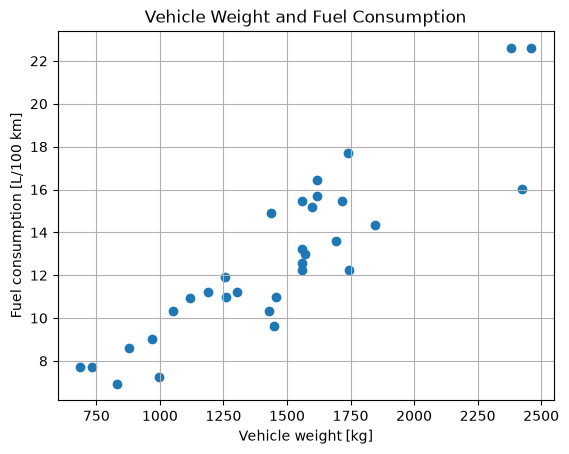

In [24]:
plt.figure()
plt.scatter(df["weight_kg"], df["fuel_l100km"])

plt.xlabel("Vehicle weight [kg]")
plt.ylabel("Fuel consumption [L/100 km]")
plt.title("Vehicle Weight and Fuel Consumption")

plt.grid(True)
plt.show()

Observe the direction, spread, and any unusual points before calculating a fit.
A trend does not mean every individual car follows it exactly.

### Minimal examples: histogram and bar chart

Histogram bins are intervals of a numeric measurement. Bar-chart positions
are distinct categories. They answer different questions.


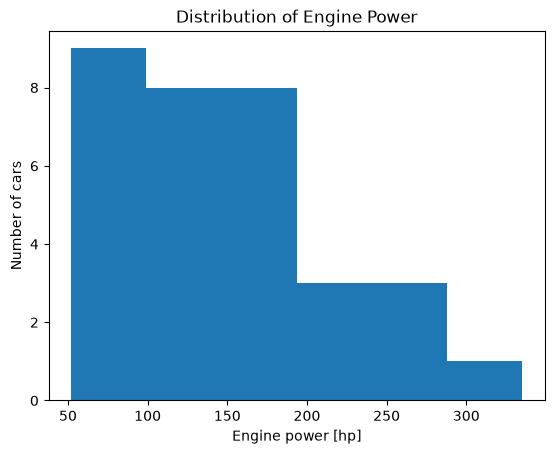

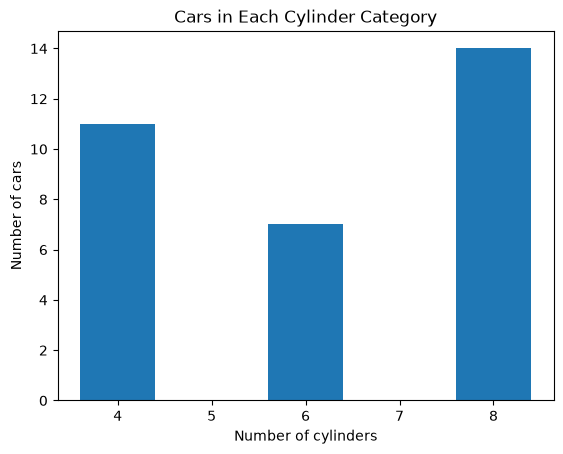

In [28]:
# Histogram: distribution of engine power
plt.hist(df["hp"], bins=6)

plt.xlabel("Engine power [hp]")
plt.ylabel("Number of cars")
plt.title("Distribution of Engine Power")

plt.show()


# Bar chart: number of cars in each cylinder category
cylinder_counts = df["cyl"].value_counts().sort_index()

plt.bar(cylinder_counts.index, cylinder_counts.values)

plt.xlabel("Number of cylinders")
plt.ylabel("Number of cars")
plt.title("Cars in Each Cylinder Category")

plt.show()

### Repeated plotting code becomes a function

The parameters supply the data and labels. The function creates a new figure
on each call. Add `label=` to individual plotted groups and `plt.legend()`
when several groups share the same axes.


In [ ]:
def scatter_plot(x, y, xlabel, ylabel, title):
    #Draw a scatter plot in a new figure
    plt.figure()
    plt.scatter(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

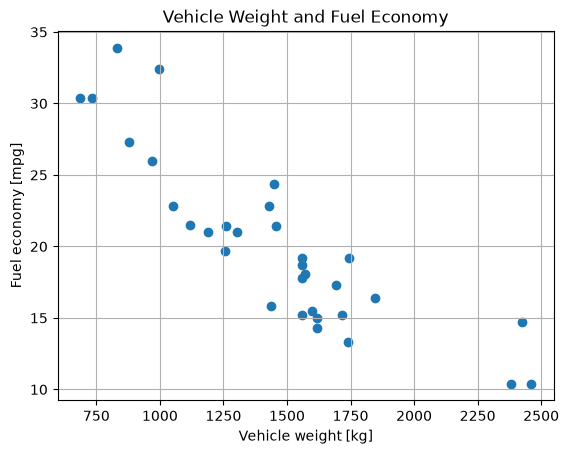

In [ ]:
scatter_plot(df['weight_kg'], df['mpg'], 'Vehicle weight [kg]', 'Fuel economy [mpg]', 'Vehicle Weight and Fuel Economy')


## A known relationship with noisy measurements

We first generate data where we know the rule:

$$y = a x + b + \text{noise}.$$

`a` is the slope, `b` the intercept, and the random term varies between
`-noise` and `+noise`. The function returns two lists. Default arguments
allow us to omit `x_start` and `x_step`.


In [30]:
def generate_points(n, slope, intercept, noise, x_start=0, x_step=1):
  
    x_values = []
    y_values = []

    for i in range(n):
        x = x_start + i * x_step
        error = random.uniform(-noise, noise)
        y = slope * x + intercept + error

        x_values.append(x)
        y_values.append(y)

    return x_values, y_values

In [31]:
random.seed(7)

true_slope = 2.5
true_intercept = 5

x_points, y_points = generate_points(
    n=25,
    slope=true_slope,
    intercept=true_intercept,
    noise=5
)

print("x:", x_points[:5])
print("y:", [round(y, 2) for y in y_points[:5]])

x: [0, 1, 2, 3, 4]
y: [3.24, 4.01, 11.51, 8.22, 15.36]


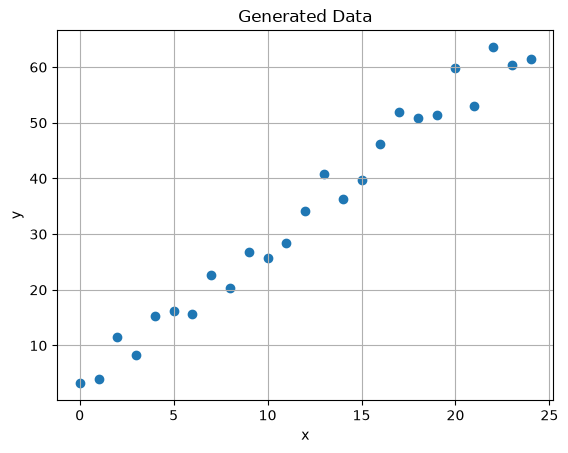

In [32]:
scatter_plot(x_points, y_points, "x", "y", "Generated Data")

`random.seed(7)` makes this example repeatable. Noise means the points do
not lie exactly on the generating line. Before fitting, estimate the direction
of the relationship and where a representative straight line should lie.

## Fit a straight line

The fitted line is $\hat y = a x + b$, where $\hat y$ is a predicted value.
`np.polyfit(x, y, 1)` fits degree 1 and returns slope, then intercept.
It sees the points, not the generating parameters.


In [33]:
fitted_slope, fitted_intercept = np.polyfit(x_points, y_points, 1)

print(f"True slope:       {true_slope}")
print(f"Fitted slope:     {fitted_slope:.2f}")

print(f"True intercept:   {true_intercept}")
print(f"Fitted intercept: {fitted_intercept:.2f}")

True slope:       2.5
Fitted slope:     2.60
True intercept:   5
Fitted intercept: 2.72


Use `np.linspace()` to create ordered x-values for drawing the fitted line.
The data stay as a scatter plot; the mathematical relationship is drawn as a line.


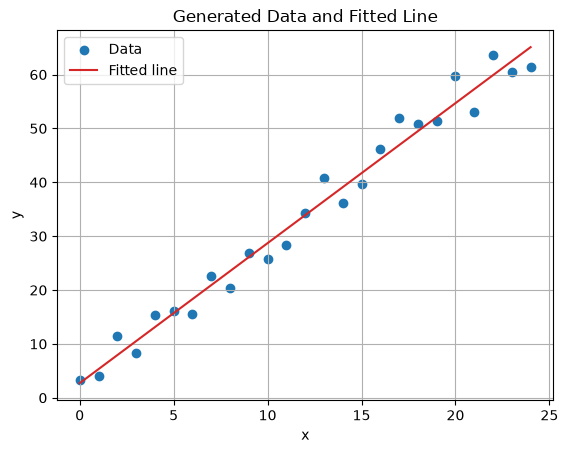

In [49]:
def plot_with_line(x, y, slope, intercept, xlabel, ylabel, title):
    x_line = [min(x), max(x)]
    y_line = [ slope * x_line[0] + intercept, slope * x_line[1] + intercept ]

    plt.figure()
    plt.scatter(x, y, label='Data')
    plt.plot(x_line, y_line , color='tab:red', label='Fitted line')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_with_line(x_points, y_points, fitted_slope, fitted_intercept, 'x', 'y', 'Generated Data and Fitted Line')





### Residuals and least squares

A residual is $y_i - \hat y_i$: the measured value minus its prediction.
It is positive above the line and negative below it.
Least squares chooses the slope and intercept that minimize
$\mathrm{SSE} = \sum_i (y_i - \hat y_i)^2$.
Squaring prevents positive and negative errors from cancelling.




In [50]:
def fit_line(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept


fitted_slope, fitted_intercept = fit_line(x_points, y_points)

print("Slope:", fitted_slope)
print("Intercept:", fitted_intercept)

Slope: 2.5987889588725293
Intercept: 2.7182430932583967


## One worked regression with real data

We use weight to describe fuel consumption in these historical cars.
Predict the sign of the slope before running the cell.


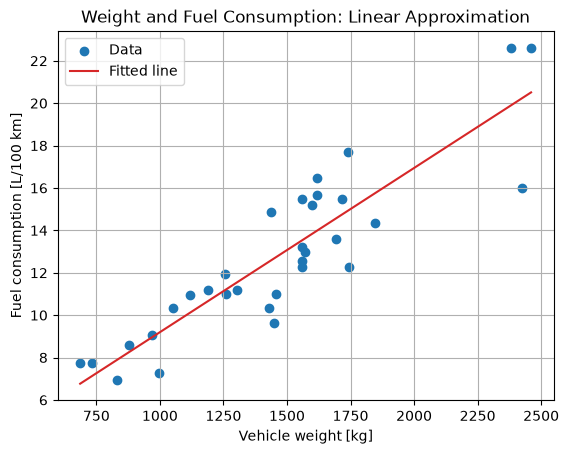

In [ ]:
slope, intercept = fit_line(df['weight_kg'], df['fuel_l100km'])



plot_with_line(df['weight_kg'], df['fuel_l100km'], slope, intercept, 'Vehicle weight [kg]', 'Fuel consumption [L/100 km]', 'Weight and Fuel Consumption: Linear Approximation')


The slope describes the change in predicted fuel consumption per kg.
Multiply it by 100 to describe a 100 kg difference. Say **“is associated with”**,
because other properties, such as engine size and power, vary with weight.

The intercept is the prediction at 0 kg. That is not a real car or a point
within the measurements, so it has no supported physical interpretation here.
Vehicle fuel consumption also depends on drag, drivetrain, and driving conditions;
it is not determined by mass alone.

The exercises ask you to compare mpg with L/100 km, inspect residuals,
and judge whether a straight line is a reasonable approximation.

## Predict and check the measured range

A prediction is an estimate. A value within the measured range is an
**interpolation**; a value outside it is an **extrapolation**.
Being inside the range does not guarantee accuracy or make the model applicable
to a different population, such as modern cars.


In [54]:
weight = 1500

predicted_fuel = fuel_slope * weight + fuel_intercept

print("Predicted fuel consumption:", predicted_fuel)

Predicted fuel consumption: 13.070180372586949


## Reference for independent practice

| Task | Useful syntax |
|---|---|
| Read a semicolon CSV | `pd.read_csv(filename, sep=';')` |
| Inspect | `.head()`, `.shape`, `.dtypes`, `.info()`, `.describe()` |
| Select | `df['column']`, `df[['column1', 'column2']]` |
| Row selection | `.iloc[position]`, `.loc[label, 'column']` |
| Filter | `df[mask]`; combine comparisons with `&`, `\|`, `~` |
| Allowed values | `df['column'].isin([value1, value2])` |
| Summarise | `.mean()`, `.median()`, `.min()`, `.max()`, `.value_counts()` |
| Find a maximum label | `.idxmax()` |
| Sort / group | `.sort_values(...)`, `.groupby(...)[...].agg(...)` |
| Separate figure | `plt.figure()` |
| Plot types | `plt.scatter(x, y)`, `plt.hist(values, bins=...)`, `plt.bar(categories, heights)` |
| Plot labels | `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)` |
| Multiple groups | `label=...` in each plot call, then `plt.legend()` |
| Draw a line | `plt.plot(x_line, y_line)` |
| Fit | `np.polyfit(x, y, 1)` returns slope, intercept |
| Prediction / residual | `slope * x + intercept`; `observed - predicted` |

Next: open the  exercise notebook. Make a prediction or a choice before coding, then compare it with the evidence you produce.
